In [ ]:
!pip install gurobipy --quiet
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
import gurobipy as gp
from gurobipy import GRB
print("Gurobi version:", gp.gurobi.version())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 28.9 MB/s eta 0:00:00
Gurobi version: (13, 0, 2)


In [ ]:
def generate_instance(n, m, p, S, seed):
    """
    n: number of communities
    m: number of candidate sites
    p: number of facilities to open
    S: impact radius (a community is impacted if within S of any open site)
    seed: RNG seed for reproducibility
    """
    rng = np.random.default_rng(seed)
    comm_xy = rng.uniform(0, 100, size=(n, 2))
    site_xy = rng.uniform(0, 100, size=(m, 2))
    a = rng.integers(100, 10_001, size=n)            # populations
    d = np.linalg.norm(comm_xy[:, None, :] - site_xy[None, :, :], axis=2)
    N = [np.where(d[i] <= S)[0].tolist() for i in range(n)]   # dangerous sites for i
    return {"a": a, "d": d, "N": N,
            "n": n, "m": m, "p": p, "S": S,
            "comm_xy": comm_xy, "site_xy": site_xy, "seed": seed}

# quick test
inst = generate_instance(n=30, m=15, p=3, S=20, seed=1)
print(f"n={inst['n']}, m={inst['m']}, p={inst['p']}, S={inst['S']}")
print(f"Populations (first 5): {inst['a'][:5]}")
print(f"Sites within radius of community 0: {inst['N'][0]}")
print(f"Communities with at least one dangerous site: "
      f"{sum(1 for Ni in inst['N'] if len(Ni) > 0)} / {inst['n']}")

n=30, m=15, p=3, S=20
Populations (first 5): [ 411 6944 7468 1868 5648]
Sites within radius of community 0: [8]
Communities with at least one dangerous site: 27 / 30


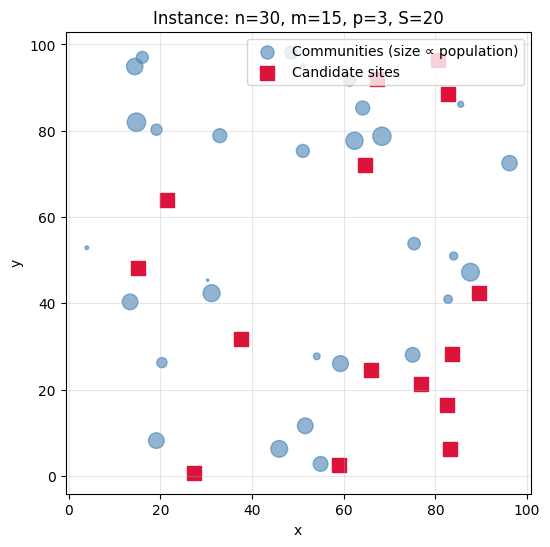

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(inst["comm_xy"][:, 0], inst["comm_xy"][:, 1],
            s=inst["a"] / 50, c="steelblue", alpha=0.6,
            label="Communities (size ∝ population)")
plt.scatter(inst["site_xy"][:, 0], inst["site_xy"][:, 1],
            s=100, marker="s", c="crimson",
            label="Candidate sites")
plt.legend(loc="upper right")
plt.title(f"Instance: n={inst['n']}, m={inst['m']}, p={inst['p']}, S={inst['S']}")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
def solve_milp(inst, time_limit=120, verbose=False):
    """
    Church-Cohon (1976) Minimum-Impact Location Problem.
    Variables:
        x_j = 1 if site j is NOT used, 0 if a facility is opened at j
        y_i = 1 if community i is within the impact zone of some open facility
    """
    a, N, m, p, n = inst["a"], inst["N"], inst["m"], inst["p"], inst["n"]

    model = gp.Model("MILP_ChurchCohon")
    model.Params.TimeLimit = time_limit
    model.Params.OutputFlag = 1 if verbose else 0

    x = model.addVars(m, vtype=GRB.BINARY, name="x")
    y = model.addVars(n, vtype=GRB.BINARY, name="y")

    # objective: minimize impacted population
    model.setObjective(gp.quicksum(a[i] * y[i] for i in range(n)), GRB.MINIMIZE)

    # exactly p facilities open  <=>  m - p sites left vacant
    model.addConstr(gp.quicksum(x[j] for j in range(m)) == m - p, "count")

    # covering: for every community i and every dangerous site j in N_i
    for i in range(n):
        for j in N[i]:
            model.addConstr(x[j] + y[i] >= 1, name=f"cov_{i}_{j}")

    t0 = time.time()
    model.optimize()
    elapsed = time.time() - t0

    result = {
        "status":  model.Status,
        "obj":     model.ObjVal   if model.SolCount > 0 else None,
        "bound":   model.ObjBound,
        "gap_pct": (model.MIPGap * 100) if model.SolCount > 0 else None,
        "time":    elapsed,
        "nodes":   int(model.NodeCount),
        "optimal": model.Status == GRB.OPTIMAL,
    }
    # recover which sites are open
    if model.SolCount > 0:
        result["open_sites"] = [j for j in range(m) if x[j].X < 0.5]
    return result

# test on the same instance
res = solve_milp(inst, time_limit=60, verbose=True)
print("\n=== SUMMARY ===")
for k, v in res.items():
    print(f"  {k}: {v}")

Restricted license - for non-production use only - expires 2027-11-29
Set parameter TimeLimit to value 60
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
TimeLimit  60

Optimize a model with 48 rows, 45 columns and 109 nonzeros (Min)
Model fingerprint: 0xd4bd91c3
Model has 30 linear objective coefficients
Variable types: 0 continuous, 45 integer (45 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+02, 9e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+01]

Found heuristic solution: objective 32718.000000
Presolve removed 13 rows and 16 columns
Presolve time: 0.00s
Presolved: 35 rows, 29 columns, 83 nonzeros
Variable types: 0 continuous, 29 integer (29 binary)

Root relaxation: objective 1.216100e+04, 

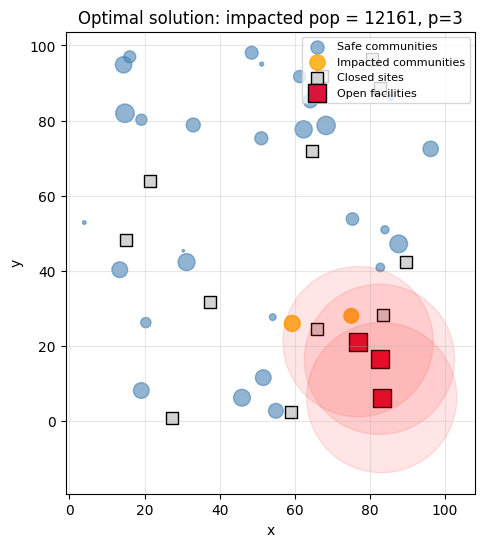

In [ ]:
plt.figure(figsize=(6, 6))
# communities: color by "impacted" (needs recomputing since we didn't return y)
open_sites = res["open_sites"]
impacted = np.zeros(inst["n"], dtype=bool)
for i in range(inst["n"]):
    if any(j in inst["N"][i] for j in open_sites):
        impacted[i] = True

plt.scatter(inst["comm_xy"][~impacted, 0], inst["comm_xy"][~impacted, 1],
            s=inst["a"][~impacted] / 50, c="steelblue", alpha=0.6, label="Safe communities")
plt.scatter(inst["comm_xy"][impacted, 0], inst["comm_xy"][impacted, 1],
            s=inst["a"][impacted] / 50, c="orange", alpha=0.8, label="Impacted communities")
# sites
closed = [j for j in range(inst["m"]) if j not in open_sites]
plt.scatter(inst["site_xy"][closed, 0], inst["site_xy"][closed, 1],
            s=80, marker="s", c="lightgray", edgecolors="black", label="Closed sites")
plt.scatter(inst["site_xy"][open_sites, 0], inst["site_xy"][open_sites, 1],
            s=150, marker="s", c="crimson", edgecolors="black", label="Open facilities")
# draw impact circles around open sites
for j in open_sites:
    circ = plt.Circle(inst["site_xy"][j], inst["S"], color="red", alpha=0.1)
    plt.gca().add_patch(circ)

plt.legend(loc="upper right", fontsize=8)
plt.title(f"Optimal solution: impacted pop = {res['obj']:.0f}, p={inst['p']}")
plt.xlabel("x"); plt.ylabel("y")
plt.gca().set_aspect("equal")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Design of experiments: 3 size classes, 40 instances total
DESIGN = []
# Small: 10 instances
for k in range(10):
    DESIGN.append(dict(cls="small",  n=30,  m=15, p=3,  S=20, seed=100 + k))
# Medium: 15 instances
for k in range(15):
    DESIGN.append(dict(cls="medium", n=80,  m=40, p=6,  S=15, seed=200 + k))
# Large: 15 instances
for k in range(15):
    DESIGN.append(dict(cls="large",  n=150, m=80, p=10, S=12, seed=300 + k))

print(f"Total instances designed: {len(DESIGN)}")
print(f"  Small : {sum(1 for d in DESIGN if d['cls']=='small')}")
print(f"  Medium: {sum(1 for d in DESIGN if d['cls']=='medium')}")
print(f"  Large : {sum(1 for d in DESIGN if d['cls']=='large')}")

Total instances designed: 40
  Small : 10
  Medium: 15
  Large : 15


In [ ]:
TIME_LIMIT = 120  # seconds per instance

rows = []
for idx, cfg in enumerate(DESIGN, start=1):
    print(f"[{idx:2d}/{len(DESIGN)}] cls={cfg['cls']:6s} "
          f"n={cfg['n']:3d} m={cfg['m']:2d} p={cfg['p']:2d} "
          f"S={cfg['S']:2d} seed={cfg['seed']} ...", end=" ", flush=True)

    inst = generate_instance(cfg["n"], cfg["m"], cfg["p"], cfg["S"], cfg["seed"])
    res  = solve_milp(inst, time_limit=TIME_LIMIT, verbose=False)

    row = {**cfg,
           "obj":       res["obj"],
           "bound":     res["bound"],
           "gap_pct":   res["gap_pct"],
           "time":      res["time"],
           "nodes":     res["nodes"],
           "optimal":   res["optimal"]}
    rows.append(row)

    tag = "OPT" if res["optimal"] else "TLE"
    print(f"{tag}  obj={res['obj']:.0f}  gap={res['gap_pct']:.2f}%  time={res['time']:.2f}s")

df = pd.DataFrame(rows)
df.to_csv("results.csv", index=False)
print(f"\nSaved {len(df)} rows to results.csv")
df.head()

[ 1/40] cls=small  n= 30 m=15 p= 3 S=20 seed=100 ... Set parameter TimeLimit to value 120
OPT  obj=6301  gap=0.00%  time=0.00s
[ 2/40] cls=small  n= 30 m=15 p= 3 S=20 seed=101 ... Set parameter TimeLimit to value 120
OPT  obj=3698  gap=0.00%  time=0.00s
[ 3/40] cls=small  n= 30 m=15 p= 3 S=20 seed=102 ... Set parameter TimeLimit to value 120
OPT  obj=6096  gap=0.00%  time=0.00s
[ 4/40] cls=small  n= 30 m=15 p= 3 S=20 seed=103 ... Set parameter TimeLimit to value 120
OPT  obj=2571  gap=0.00%  time=0.00s
[ 5/40] cls=small  n= 30 m=15 p= 3 S=20 seed=104 ... Set parameter TimeLimit to value 120
OPT  obj=9527  gap=0.00%  time=0.00s
[ 6/40] cls=small  n= 30 m=15 p= 3 S=20 seed=105 ... Set parameter TimeLimit to value 120
OPT  obj=0  gap=0.00%  time=0.00s
[ 7/40] cls=small  n= 30 m=15 p= 3 S=20 seed=106 ... Set parameter TimeLimit to value 120
OPT  obj=10321  gap=0.00%  time=0.00s
[ 8/40] cls=small  n= 30 m=15 p= 3 S=20 seed=107 ... Set parameter TimeLimit to value 120
OPT  obj=15029  gap=0.0

,cls,n,m,p,S,seed,obj,bound,gap_pct,time,nodes,optimal
0,small,30,15,3,20,100,6301.0,6301.0,0.0,0.001553,1,True
1,small,30,15,3,20,101,3698.0,3698.0,0.0,0.001734,1,True
2,small,30,15,3,20,102,6096.0,6096.0,0.0,0.001682,1,True
3,small,30,15,3,20,103,2571.0,2571.0,0.0,0.001512,1,True
4,small,30,15,3,20,104,9527.0,9527.0,0.0,0.001446,1,True


In [ ]:
# Design v2: push the solver until it starts to sweat
DESIGN2 = []
# Small (baseline, keep for reference)
for k in range(8):
    DESIGN2.append(dict(cls="small",  n=50,   m=25,  p=4,  S=15, seed=100+k))
# Medium
for k in range(10):
    DESIGN2.append(dict(cls="medium", n=200,  m=100, p=15, S=10, seed=200+k))
# Large
for k in range(10):
    DESIGN2.append(dict(cls="large",  n=500,  m=250, p=25, S=8,  seed=300+k))
# XL — this is where Gurobi should start needing seconds/minutes
for k in range(7):
    DESIGN2.append(dict(cls="xl",     n=1000, m=500, p=50, S=6,  seed=400+k))
# XXL — should hit the 120s timeout in several cases
for k in range(5):
    DESIGN2.append(dict(cls="xxl",    n=2000, m=1000, p=100, S=5, seed=500+k))

print(f"Total instances designed: {len(DESIGN2)}")
for cls in ["small", "medium", "large", "xl", "xxl"]:
    print(f"  {cls:6s}: {sum(1 for d in DESIGN2 if d['cls']==cls)}")

Total instances designed: 40
  small : 8
  medium: 10
  large : 10
  xl    : 7
  xxl   : 5


In [ ]:
TIME_LIMIT = 120

rows2 = []
for idx, cfg in enumerate(DESIGN2, start=1):
    print(f"[{idx:2d}/{len(DESIGN2)}] cls={cfg['cls']:6s} "
          f"n={cfg['n']:4d} m={cfg['m']:4d} p={cfg['p']:3d} "
          f"S={cfg['S']:2d} seed={cfg['seed']} ...", end=" ", flush=True)

    inst = generate_instance(cfg["n"], cfg["m"], cfg["p"], cfg["S"], cfg["seed"])
    res  = solve_milp(inst, time_limit=TIME_LIMIT, verbose=False)

    row = {**cfg,
           "obj":      res["obj"],
           "bound":    res["bound"],
           "gap_pct":  res["gap_pct"],
           "time":     res["time"],
           "nodes":    res["nodes"],
           "optimal":  res["optimal"]}
    rows2.append(row)

    tag = "OPT" if res["optimal"] else "TLE"
    print(f"{tag}  obj={res['obj']:.0f}  gap={res['gap_pct']:.2f}%  "
          f"time={res['time']:.1f}s  nodes={res['nodes']}")

df2 = pd.DataFrame(rows2)
df2.to_csv("results_v2.csv", index=False)
print(f"\nSaved {len(df2)} rows to results_v2.csv")

[ 1/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=100 ... Set parameter TimeLimit to value 120
OPT  obj=2579  gap=0.00%  time=0.0s  nodes=1
[ 2/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=101 ... Set parameter TimeLimit to value 120
OPT  obj=7059  gap=0.00%  time=0.0s  nodes=1
[ 3/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=102 ... Set parameter TimeLimit to value 120
OPT  obj=2231  gap=0.00%  time=0.0s  nodes=1
[ 4/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=103 ... Set parameter TimeLimit to value 120
OPT  obj=6198  gap=0.00%  time=0.0s  nodes=1
[ 5/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=104 ... Set parameter TimeLimit to value 120
OPT  obj=5472  gap=0.00%  time=0.0s  nodes=1
[ 6/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=105 ... Set parameter TimeLimit to value 120
OPT  obj=1153  gap=0.00%  time=0.0s  nodes=1
[ 7/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=106 ... Set parameter TimeLimit to value 120
OPT  obj=4090  gap=0.00%  time=0.0s  nodes=1
[ 8/40] cls=small  n=  50 m

GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information

In [ ]:
!pip install pulp --quiet
import pulp

def solve_milp_pulp(inst, time_limit=120, verbose=False):
    """
    Church-Cohon (1976) MILP via PuLP + CBC (open-source).
    Solves LP relaxation first (for lower bound), then MILP with time limit.
    """
    a, N, m, p, n = inst["a"], inst["N"], inst["m"], inst["p"], inst["n"]

    # ---------- 1) LP relaxation for lower bound ----------
    lp = pulp.LpProblem("Relax", pulp.LpMinimize)
    x_lp = [pulp.LpVariable(f"x_{j}", lowBound=0, upBound=1) for j in range(m)]
    y_lp = [pulp.LpVariable(f"y_{i}", lowBound=0, upBound=1) for i in range(n)]
    lp += pulp.lpSum(a[i] * y_lp[i] for i in range(n))
    lp += pulp.lpSum(x_lp) == m - p
    for i in range(n):
        for j in N[i]:
            lp += x_lp[j] + y_lp[i] >= 1
    t0 = time.time()
    lp.solve(pulp.PULP_CBC_CMD(msg=0))
    lp_time  = time.time() - t0
    lp_bound = pulp.value(lp.objective) if lp.status == 1 else None

    # ---------- 2) MILP for upper bound (best integer sol) ----------
    milp = pulp.LpProblem("MILP", pulp.LpMinimize)
    x = [pulp.LpVariable(f"x_{j}", cat="Binary") for j in range(m)]
    y = [pulp.LpVariable(f"y_{i}", cat="Binary") for i in range(n)]
    milp += pulp.lpSum(a[i] * y[i] for i in range(n))
    milp += pulp.lpSum(x) == m - p
    for i in range(n):
        for j in N[i]:
            milp += x[j] + y[i] >= 1
    t0 = time.time()
    milp.solve(pulp.PULP_CBC_CMD(msg=1 if verbose else 0, timeLimit=time_limit))
    milp_time = time.time() - t0

    obj = pulp.value(milp.objective) if milp.status in (1, 0) else None
    optimal = (milp.status == 1)  # 1 = Optimal in PuLP
    gap_pct = (100.0 * (obj - lp_bound) / obj) if (obj and lp_bound is not None and obj > 0) else None

    result = {
        "status":   milp.status,
        "obj":      obj,
        "bound":    lp_bound,
        "gap_pct":  gap_pct,
        "time":     milp_time,
        "lp_time":  lp_time,
        "optimal":  optimal,
    }
    if obj is not None:
        result["open_sites"] = [j for j in range(m) if x[j].value() < 0.5]
    return result

In [ ]:
# Pequeña — debería dar mismo óptimo que Gurobi (12161)
inst_small = generate_instance(n=30, m=15, p=3, S=20, seed=1)
res_s = solve_milp_pulp(inst_small, time_limit=30)
print(f"SMALL:   obj={res_s['obj']:.0f}  bound={res_s['bound']:.2f}  "
      f"gap={res_s['gap_pct']:.2f}%  time={res_s['time']:.2f}s  optimal={res_s['optimal']}")

# Grande — para ver que ya no salta el límite
inst_large = generate_instance(n=1000, m=500, p=50, S=6, seed=400)
res_l = solve_milp_pulp(inst_large, time_limit=60)
print(f"LARGE:   obj={res_l['obj']:.0f}  bound={res_l['bound']:.2f}  "
      f"gap={res_l['gap_pct']:.2f}%  time={res_l['time']:.2f}s  optimal={res_l['optimal']}")

SMALL:   obj=12161  bound=12161.00  gap=0.00%  time=0.04s  optimal=True
LARGE:   obj=332806  bound=330343.40  gap=0.74%  time=3.12s  optimal=True


In [ ]:
TIME_LIMIT = 120

rows2 = []
for idx, cfg in enumerate(DESIGN2, start=1):
    print(f"[{idx:2d}/{len(DESIGN2)}] cls={cfg['cls']:6s} "
          f"n={cfg['n']:4d} m={cfg['m']:4d} p={cfg['p']:3d} "
          f"S={cfg['S']:2d} seed={cfg['seed']} ...", end=" ", flush=True)

    inst = generate_instance(cfg["n"], cfg["m"], cfg["p"], cfg["S"], cfg["seed"])
    res  = solve_milp_pulp(inst, time_limit=TIME_LIMIT, verbose=False)

    row = {**cfg,
           "obj":      res["obj"],
           "bound":    res["bound"],
           "gap_pct":  res["gap_pct"],
           "time":     res["time"],
           "lp_time":  res["lp_time"],
           "optimal":  res["optimal"]}
    rows2.append(row)

    tag = "OPT" if res["optimal"] else "TLE"
    obj_str  = f"{res['obj']:.0f}"    if res['obj']     is not None else "—"
    gap_str  = f"{res['gap_pct']:.2f}%" if res['gap_pct'] is not None else "—"
    print(f"{tag}  obj={obj_str}  gap={gap_str}  time={res['time']:.1f}s")

df2 = pd.DataFrame(rows2)
df2.to_csv("results_v2.csv", index=False)
print(f"\nSaved {len(df2)} rows to results_v2.csv")

[ 1/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=100 ... OPT  obj=2579  gap=26.54%  time=0.0s
[ 2/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=101 ... OPT  obj=7059  gap=0.00%  time=0.0s
[ 3/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=102 ... OPT  obj=2231  gap=0.00%  time=0.0s
[ 4/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=103 ... OPT  obj=6198  gap=0.00%  time=0.0s
[ 5/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=104 ... OPT  obj=5472  gap=4.70%  time=0.0s
[ 6/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=105 ... OPT  obj=1153  gap=33.33%  time=0.0s
[ 7/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=106 ... OPT  obj=4090  gap=3.98%  time=0.0s
[ 8/40] cls=small  n=  50 m=  25 p=  4 S=15 seed=107 ... OPT  obj=4967  gap=0.00%  time=0.0s
[ 9/40] cls=medium n= 200 m= 100 p= 15 S=10 seed=200 ... OPT  obj=71350  gap=1.17%  time=0.1s
[10/40] cls=medium n= 200 m= 100 p= 15 S=10 seed=201 ... OPT  obj=58895  gap=0.70%  time=0.1s
[11/40] cls=medium n= 200 m= 100 p= 15 S=10 seed=202 ... OPT  obj=

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
DRIVE_DIR = "/content/drive/MyDrive/AMOD_project"
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/figures", exist_ok=True)

df2.to_csv(f"{DRIVE_DIR}/results_v2.csv", index=False)
print(f"Saved {len(df2)} rows to {DRIVE_DIR}/results_v2.csv")

Mounted at /content/drive
Saved 40 rows to /content/drive/MyDrive/AMOD_project/results_v2.csv


In [ ]:
CLASS_ORDER = ["small", "medium", "large", "xl", "xxl"]

summary2 = df2.groupby("cls").agg(
    instances    = ("cls",     "count"),
    n            = ("n",       "first"),
    m            = ("m",       "first"),
    p            = ("p",       "first"),
    S            = ("S",       "first"),
    optimal_pct  = ("optimal", lambda s: 100 * s.mean()),
    avg_time_s   = ("time",    "mean"),
    max_time_s   = ("time",    "max"),
    avg_gap_pct  = ("gap_pct", "mean"),
    max_gap_pct  = ("gap_pct", "max"),
).round(3)

summary2 = summary2.reindex(CLASS_ORDER)
print(summary2.to_string())

# save as CSV and as LaTeX table for the report
summary2.to_csv(f"{DRIVE_DIR}/summary_table.csv")
with open(f"{DRIVE_DIR}/summary_table.tex", "w") as f:
    f.write(summary2.to_latex(float_format="%.3f"))
print(f"\nSaved summary_table.csv and .tex to {DRIVE_DIR}")

        instances     n     m    p   S  optimal_pct  avg_time_s  max_time_s  avg_gap_pct  max_gap_pct
cls                                                                                                  
small           8    50    25    4  15        100.0       0.012       0.023        8.570       33.333
medium         10   200   100   15  10        100.0       0.093       0.189        1.870        4.099
large          10   500   250   25   8        100.0       1.012       3.765        1.616        3.160
xl              7  1000   500   50   6        100.0       2.022       3.347        0.788        3.057
xxl             5  2000  1000  100   5        100.0      13.554      36.229        0.420        0.668

Saved summary_table.csv and .tex to /content/drive/MyDrive/AMOD_project


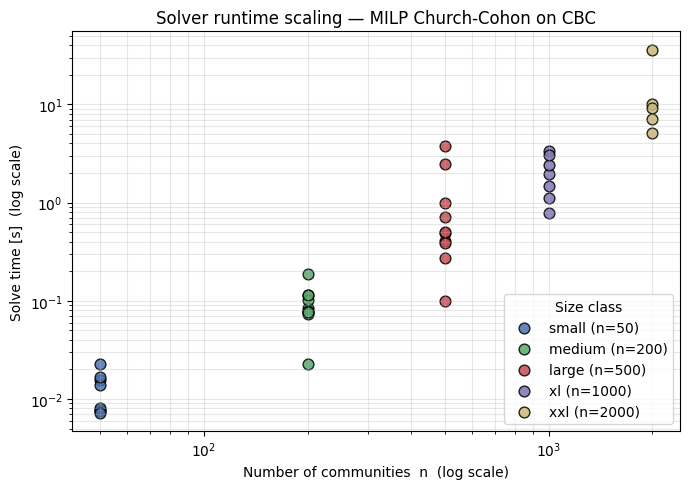

In [ ]:
plt.figure(figsize=(7, 5))
colors = {"small":"#4C72B0","medium":"#55A868","large":"#C44E52","xl":"#8172B2","xxl":"#CCB974"}

for cls in CLASS_ORDER:
    sub = df2[df2["cls"] == cls]
    plt.scatter(sub["n"], sub["time"],
                s=60, c=colors[cls], edgecolors="black",
                label=f"{cls} (n={sub['n'].iloc[0]})", alpha=0.85)

plt.xscale("log"); plt.yscale("log")
plt.xlabel("Number of communities  n  (log scale)")
plt.ylabel("Solve time [s]  (log scale)")
plt.title("Solver runtime scaling — MILP Church-Cohon on CBC")
plt.grid(True, which="both", alpha=0.3)
plt.legend(title="Size class", loc="lower right")
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/figures/fig_time_vs_n.png", dpi=200)
plt.show()

/tmp/ipykernel_510/2672353457.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_by_class, labels=CLASS_ORDER, patch_artist=True,


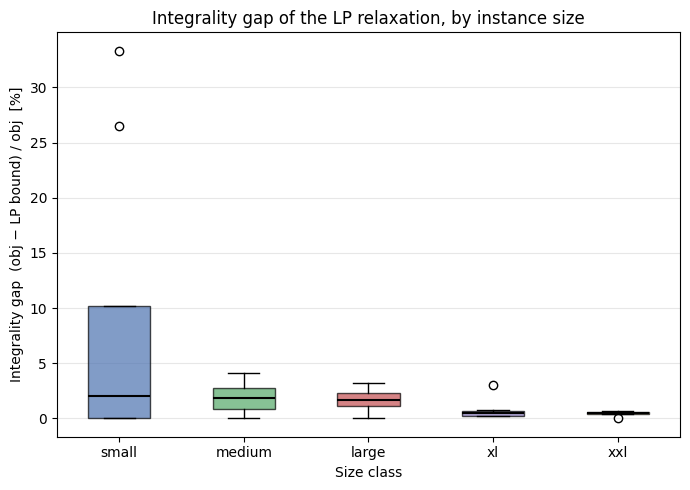

In [ ]:
plt.figure(figsize=(7, 5))
data_by_class = [df2[df2["cls"] == cls]["gap_pct"].values for cls in CLASS_ORDER]
bp = plt.boxplot(data_by_class, labels=CLASS_ORDER, patch_artist=True,
                 medianprops=dict(color="black", linewidth=1.5))
for patch, cls in zip(bp["boxes"], CLASS_ORDER):
    patch.set_facecolor(colors[cls]); patch.set_alpha(0.7)

plt.ylabel("Integrality gap  (obj − LP bound) / obj  [%]")
plt.xlabel("Size class")
plt.title("Integrality gap of the LP relaxation, by instance size")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/figures/fig_gap_by_class.png", dpi=200)
plt.show()

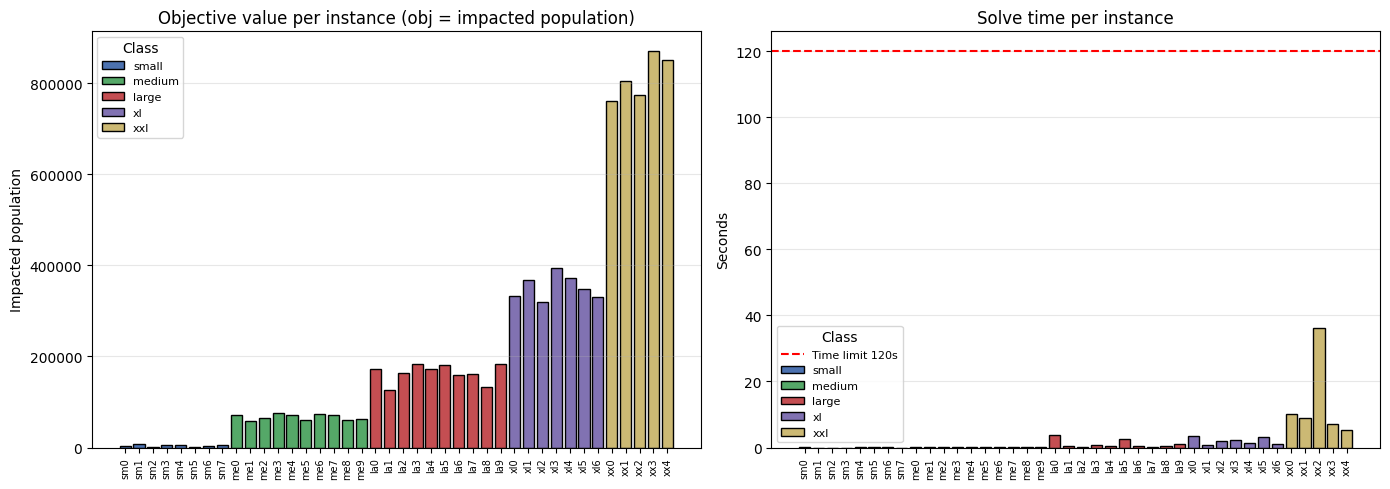

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: solution value per instance, colored by class
ax = axes[0]
for cls in CLASS_ORDER:
    sub = df2[df2["cls"] == cls].reset_index(drop=True)
    xs = [f"{cls[:2]}{i}" for i in range(len(sub))]
    ax.bar(xs, sub["obj"], color=colors[cls], edgecolor="black", label=cls)
ax.set_title("Objective value per instance (obj = impacted population)")
ax.set_ylabel("Impacted population")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.legend(title="Class", fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

# RIGHT: solve time per instance with timeout reference
ax = axes[1]
for cls in CLASS_ORDER:
    sub = df2[df2["cls"] == cls].reset_index(drop=True)
    xs = [f"{cls[:2]}{i}" for i in range(len(sub))]
    ax.bar(xs, sub["time"], color=colors[cls], edgecolor="black", label=cls)
ax.axhline(120, ls="--", c="red", label="Time limit 120s")
ax.set_title("Solve time per instance")
ax.set_ylabel("Seconds")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.legend(title="Class", fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/figures/fig_per_instance.png", dpi=200)
plt.show()

In [ ]:
def greedy_heuristic(inst):
    """
    Greedy for Church-Cohon MILP:
    At each step, open the site whose opening adds the LEAST new impacted population.
    Complexity: O(p * m * average |N_i|).
    """
    a, N_i, m, p, n = inst["a"], inst["N"], inst["m"], inst["p"], inst["n"]

    # inverse index: for each site j, which communities have j in their N_i?
    danger = [set() for _ in range(m)]
    for i in range(n):
        for j in N_i[i]:
            danger[j].add(i)

    t0 = time.time()
    open_sites = []
    impacted = set()

    for _ in range(p):
        best_j, best_delta = -1, float("inf")
        for j in range(m):
            if j in open_sites:
                continue
            new_comms = danger[j] - impacted
            delta = sum(a[i] for i in new_comms)
            if delta < best_delta:
                best_delta, best_j = delta, j
        open_sites.append(best_j)
        impacted |= danger[best_j]

    obj = int(sum(a[i] for i in impacted))
    elapsed = time.time() - t0
    return {"obj": obj, "time": elapsed, "open_sites": sorted(open_sites)}

# smoke test on same seed=1 instance we know
inst = generate_instance(n=30, m=15, p=3, S=20, seed=1)
r = greedy_heuristic(inst)
print(f"Greedy on small (opt=12161):  obj={r['obj']}  time={r['time']*1000:.2f} ms")
print(f"  open sites: {r['open_sites']}")

# and on the XXL to make sure it's fast at scale
inst_xxl = generate_instance(n=2000, m=1000, p=100, S=5, seed=500)
r = greedy_heuristic(inst_xxl)
print(f"\nGreedy on xxl:  obj={r['obj']}  time={r['time']*1000:.2f} ms")

Greedy on small (opt=12161):  obj=12161  time=0.11 ms
  open sites: [11, 12, 13]

Greedy on xxl:  obj=1016821  time=344.57 ms


In [ ]:
rows_h = []
for idx, cfg in enumerate(DESIGN2, start=1):
    inst = generate_instance(cfg["n"], cfg["m"], cfg["p"], cfg["S"], cfg["seed"])
    r    = greedy_heuristic(inst)
    rows_h.append({**cfg, "obj_heur": r["obj"], "time_heur": r["time"]})
    print(f"[{idx:2d}/{len(DESIGN2)}] cls={cfg['cls']:6s}  "
          f"obj_heur={r['obj']:>8}  time_heur={r['time']*1000:.1f} ms")

df_h = pd.DataFrame(rows_h)

# merge with the solver results
df_cmp = df2.merge(
    df_h[["cls","n","m","p","S","seed","obj_heur","time_heur"]],
    on=["cls","n","m","p","S","seed"]
)
df_cmp["obj_ratio"]   = df_cmp["obj_heur"] / df_cmp["obj"]
df_cmp["speedup"]     = df_cmp["time"]     / df_cmp["time_heur"]
df_cmp["heur_gap_pct"] = 100 * (df_cmp["obj_heur"] - df_cmp["obj"]) / df_cmp["obj"]

df_cmp.to_csv(f"{DRIVE_DIR}/results_comparison.csv", index=False)
print(f"\nSaved comparison to {DRIVE_DIR}/results_comparison.csv")

# summary
cmp_summary = df_cmp.groupby("cls").agg(
    avg_ratio     = ("obj_ratio",   "mean"),
    max_ratio     = ("obj_ratio",   "max"),
    avg_heur_gap  = ("heur_gap_pct","mean"),
    max_heur_gap  = ("heur_gap_pct","max"),
    avg_speedup   = ("speedup",     "mean"),
    max_speedup   = ("speedup",     "max"),
).round(3).reindex(CLASS_ORDER)
print(cmp_summary.to_string())

# save summary as latex
with open(f"{DRIVE_DIR}/comparison_table.tex", "w") as f:
    f.write(cmp_summary.to_latex(float_format="%.3f"))

[ 1/40] cls=small   obj_heur=    2579  time_heur=0.2 ms
[ 2/40] cls=small   obj_heur=    7059  time_heur=0.1 ms
[ 3/40] cls=small   obj_heur=    2231  time_heur=0.2 ms
[ 4/40] cls=small   obj_heur=    7221  time_heur=0.1 ms
[ 5/40] cls=small   obj_heur=    5472  time_heur=0.2 ms
[ 6/40] cls=small   obj_heur=    1153  time_heur=0.1 ms
[ 7/40] cls=small   obj_heur=    5749  time_heur=0.2 ms
[ 8/40] cls=small   obj_heur=    4967  time_heur=0.1 ms
[ 9/40] cls=medium  obj_heur=  100463  time_heur=1.9 ms
[10/40] cls=medium  obj_heur=   61369  time_heur=2.1 ms
[11/40] cls=medium  obj_heur=   95362  time_heur=2.0 ms
[12/40] cls=medium  obj_heur=   87069  time_heur=2.0 ms
[13/40] cls=medium  obj_heur=  117638  time_heur=2.0 ms
[14/40] cls=medium  obj_heur=   72811  time_heur=2.0 ms
[15/40] cls=medium  obj_heur=   79097  time_heur=2.0 ms
[16/40] cls=medium  obj_heur=   84938  time_heur=1.9 ms
[17/40] cls=medium  obj_heur=   83793  time_heur=2.1 ms
[18/40] cls=medium  obj_heur=   67213  time_heur

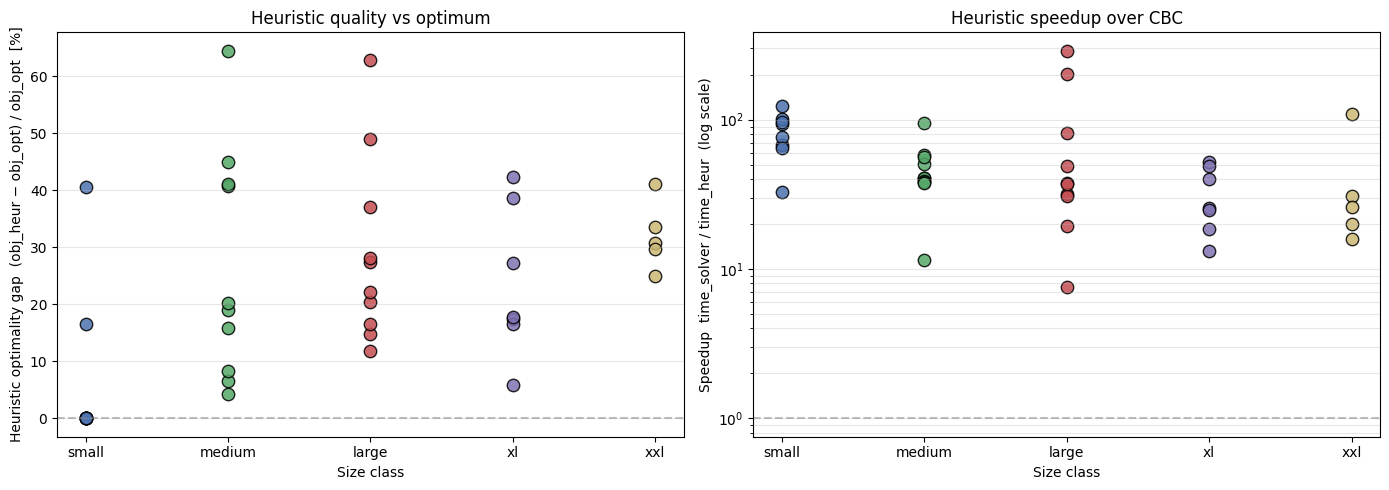

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: heur/solver quality ratio (log-scale for clarity)
ax = axes[0]
for cls in CLASS_ORDER:
    sub = df_cmp[df_cmp["cls"] == cls]
    ax.scatter([cls]*len(sub), sub["heur_gap_pct"],
               s=80, c=colors[cls], edgecolors="black", alpha=0.85)
ax.axhline(0, ls="--", c="gray", alpha=0.5)
ax.set_ylabel("Heuristic optimality gap  (obj_heur − obj_opt) / obj_opt  [%]")
ax.set_xlabel("Size class")
ax.set_title("Heuristic quality vs optimum")
ax.grid(True, axis="y", alpha=0.3)

# RIGHT: speedup (log-scale)
ax = axes[1]
for cls in CLASS_ORDER:
    sub = df_cmp[df_cmp["cls"] == cls]
    ax.scatter([cls]*len(sub), sub["speedup"],
               s=80, c=colors[cls], edgecolors="black", alpha=0.85)
ax.set_yscale("log")
ax.axhline(1, ls="--", c="gray", alpha=0.5)
ax.set_ylabel("Speedup  time_solver / time_heur  (log scale)")
ax.set_xlabel("Size class")
ax.set_title("Heuristic speedup over CBC")
ax.grid(True, axis="y", which="both", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/figures/fig_heur_vs_solver.png", dpi=200)
plt.show()

In [ ]:
# HUGE class — probing whether CBC still terminates within 120s at n=3000
DESIGN_HUGE = [dict(cls="huge", n=3000, m=1500, p=150, S=4, seed=600+k) for k in range(5)]

rows_huge = []
for idx, cfg in enumerate(DESIGN_HUGE, start=1):
    print(f"[{idx}/5] HUGE  n={cfg['n']}  m={cfg['m']}  p={cfg['p']}  "
          f"S={cfg['S']}  seed={cfg['seed']} ...", flush=True)

    inst = generate_instance(cfg["n"], cfg["m"], cfg["p"], cfg["S"], cfg["seed"])

    # solver
    print("  solver ...", end=" ", flush=True)
    r_s = solve_milp_pulp(inst, time_limit=120, verbose=False)
    tag = "OPT" if r_s["optimal"] else "TLE"
    obj_str = f"{r_s['obj']:.0f}"     if r_s['obj']     is not None else "—"
    gap_str = f"{r_s['gap_pct']:.2f}%" if r_s['gap_pct'] is not None else "—"
    print(f"{tag}  obj={obj_str}  gap={gap_str}  time={r_s['time']:.1f}s")

    # heuristic
    print("  greedy ...", end=" ", flush=True)
    r_h = greedy_heuristic(inst)
    print(f"obj={r_h['obj']}  time={r_h['time']*1000:.1f} ms")

    rows_huge.append({**cfg,
                      "obj":       r_s["obj"],
                      "bound":     r_s["bound"],
                      "gap_pct":   r_s["gap_pct"],
                      "time":      r_s["time"],
                      "lp_time":   r_s["lp_time"],
                      "optimal":   r_s["optimal"],
                      "obj_heur":  r_h["obj"],
                      "time_heur": r_h["time"]})

df_huge = pd.DataFrame(rows_huge)
df_huge["obj_ratio"]    = df_huge["obj_heur"] / df_huge["obj"]
df_huge["speedup"]      = df_huge["time"]     / df_huge["time_heur"]
df_huge["heur_gap_pct"] = 100 * (df_huge["obj_heur"] - df_huge["obj"]) / df_huge["obj"]

# combine into a full DataFrame
df_full = pd.concat([df_cmp, df_huge], ignore_index=True)
df_full.to_csv(f"{DRIVE_DIR}/results_full.csv", index=False)
print(f"\nTotal instances now: {len(df_full)}")
print(f"  TLE (solver): {(~df_full['optimal']).sum()}")

[1/5] HUGE  n=3000  m=1500  p=150  S=4  seed=600 ...
  solver ... OPT  obj=1222062  gap=1.34%  time=33.2s
  greedy ... obj=1472181  time=1039.3 ms
[2/5] HUGE  n=3000  m=1500  p=150  S=4  seed=601 ...
  solver ... OPT  obj=1132824  gap=0.23%  time=13.6s
  greedy ... obj=1417074  time=785.9 ms
[3/5] HUGE  n=3000  m=1500  p=150  S=4  seed=602 ...
  solver ... OPT  obj=1201887  gap=0.05%  time=20.2s
  greedy ... obj=1455437  time=791.8 ms
[4/5] HUGE  n=3000  m=1500  p=150  S=4  seed=603 ...
  solver ... OPT  obj=1320831  gap=0.20%  time=27.0s
  greedy ... obj=1642458  time=794.0 ms
[5/5] HUGE  n=3000  m=1500  p=150  S=4  seed=604 ...
  solver ... OPT  obj=1171466  gap=0.17%  time=8.3s
  greedy ... obj=1436983  time=793.1 ms

Total instances now: 45
  TLE (solver): 0


        instances  optimal_pct  avg_time_s  max_time_s  avg_gap_pct  avg_heur_gap  avg_speedup
cls                                                                                           
small           8        100.0       0.012       0.023        8.570         7.133       81.910
medium         10        100.0       0.093       0.189        1.870        26.546       46.758
large          10        100.0       1.012       3.765        1.616        29.030       78.576
xl              7        100.0       2.022       3.347        0.788        23.720       31.903
xxl             5        100.0      13.554      36.229        0.420        32.037       40.350
huge            5        100.0      20.469      33.230        0.399        22.734       23.857


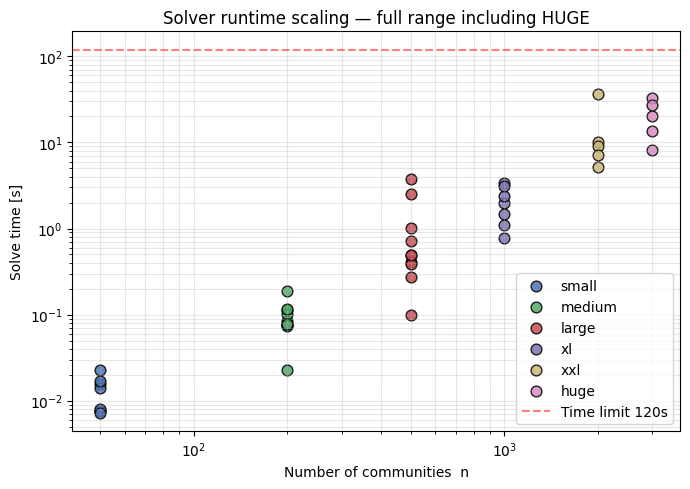

In [ ]:
CLASS_ORDER_FULL = CLASS_ORDER + ["huge"]
colors["huge"] = "#DA8BC3"

# updated summary
summary_full = df_full.groupby("cls").agg(
    instances     = ("cls",         "count"),
    optimal_pct   = ("optimal",     lambda s: 100 * s.mean()),
    avg_time_s    = ("time",        "mean"),
    max_time_s    = ("time",        "max"),
    avg_gap_pct   = ("gap_pct",     "mean"),
    avg_heur_gap  = ("heur_gap_pct","mean"),
    avg_speedup   = ("speedup",     "mean"),
).round(3).reindex(CLASS_ORDER_FULL)
print(summary_full.to_string())

with open(f"{DRIVE_DIR}/summary_full.tex", "w") as f:
    f.write(summary_full.to_latex(float_format="%.3f"))

# updated log-log time plot with the huge points
plt.figure(figsize=(7, 5))
for cls in CLASS_ORDER_FULL:
    sub = df_full[df_full["cls"] == cls]
    plt.scatter(sub["n"], sub["time"], s=60, c=colors[cls],
                edgecolors="black", label=f"{cls}", alpha=0.85)
plt.axhline(120, ls="--", c="red", alpha=0.5, label="Time limit 120s")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Number of communities  n"); plt.ylabel("Solve time [s]")
plt.title("Solver runtime scaling — full range including HUGE")
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/figures/fig_time_full.png", dpi=200)
plt.show()

In [ ]:
# Sensitivity on S: fix problem size, vary impact radius
DESIGN_SENS = []
for S in [4, 6, 8, 10, 12]:
    for k in range(3):
        DESIGN_SENS.append(dict(cls=f"S={S}", n=1000, m=500, p=50, S=S, seed=700 + S*10 + k))

rows_sens = []
for idx, cfg in enumerate(DESIGN_SENS, start=1):
    print(f"[{idx:2d}/{len(DESIGN_SENS)}] S={cfg['S']:2d}  seed={cfg['seed']} ...", end=" ", flush=True)

    inst = generate_instance(cfg["n"], cfg["m"], cfg["p"], cfg["S"], cfg["seed"])
    # coverage density: average |N_i| per community
    avg_Ni = np.mean([len(Ni) for Ni in inst["N"]])
    frac_covered = np.mean([len(Ni) > 0 for Ni in inst["N"]])

    r_s = solve_milp_pulp(inst, time_limit=120, verbose=False)
    r_h = greedy_heuristic(inst)

    row = {**cfg,
           "avg_Ni":       round(avg_Ni, 2),
           "frac_covered": round(frac_covered, 3),
           "obj":          r_s["obj"],
           "bound":        r_s["bound"],
           "gap_pct":      r_s["gap_pct"],
           "time":         r_s["time"],
           "optimal":      r_s["optimal"],
           "obj_heur":     r_h["obj"],
           "time_heur":    r_h["time"]}
    row["heur_gap_pct"] = 100 * (r_h["obj"] - r_s["obj"]) / r_s["obj"]
    rows_sens.append(row)

    print(f"|N|={avg_Ni:5.1f}  cov={frac_covered:.2f}  "
          f"obj={r_s['obj']:.0f}  gap={r_s['gap_pct']:.2f}%  "
          f"time={r_s['time']:.2f}s  heur_gap={row['heur_gap_pct']:.1f}%")

df_sens = pd.DataFrame(rows_sens)
df_sens.to_csv(f"{DRIVE_DIR}/results_sensitivity.csv", index=False)
print(f"\nSaved {len(df_sens)} rows to results_sensitivity.csv")

[ 1/15] S= 4  seed=740 ... |N|=  2.4  cov=0.90  obj=132830  gap=0.00%  time=0.10s  heur_gap=27.9%
[ 2/15] S= 4  seed=741 ... |N|=  2.5  cov=0.93  obj=107206  gap=0.11%  time=0.68s  heur_gap=44.1%
[ 3/15] S= 4  seed=742 ... |N|=  2.4  cov=0.91  obj=130441  gap=0.00%  time=0.10s  heur_gap=21.4%
[ 4/15] S= 6  seed=760 ... |N|=  5.3  cov=1.00  obj=315561  gap=0.49%  time=0.60s  heur_gap=35.0%
[ 5/15] S= 6  seed=761 ... |N|=  5.3  cov=0.99  obj=374895  gap=1.60%  time=1.54s  heur_gap=55.4%
[ 6/15] S= 6  seed=762 ... |N|=  5.5  cov=0.99  obj=337001  gap=1.20%  time=2.95s  heur_gap=21.2%
[ 7/15] S= 8  seed=780 ... |N|=  9.1  cov=1.00  obj=396424  gap=2.35%  time=3.74s  heur_gap=48.2%
[ 8/15] S= 8  seed=781 ... |N|=  9.2  cov=1.00  obj=452171  gap=3.14%  time=3.59s  heur_gap=14.4%
[ 9/15] S= 8  seed=782 ... |N|=  9.3  cov=1.00  obj=396197  gap=1.20%  time=6.61s  heur_gap=29.9%
[10/15] S=10  seed=800 ... |N|= 14.4  cov=1.00  obj=467667  gap=3.97%  time=16.23s  heur_gap=1.6%
[11/15] S=10  seed=8

    seeds  avg_Ni  frac_covered  avg_time_s  avg_gap_pct     avg_obj  avg_heur_gap
S                                                                                 
4       3   2.420         0.914       0.293        0.037  123492.333        31.158
6       3   5.357         0.994       1.694        1.096  342485.667        37.229
8       3   9.207         1.000       4.646        2.229  414930.667        30.847
10      3  14.373         1.000      85.853       14.164  571017.000         7.629
12      3  20.313         1.000     125.116       37.000  816874.333         3.867


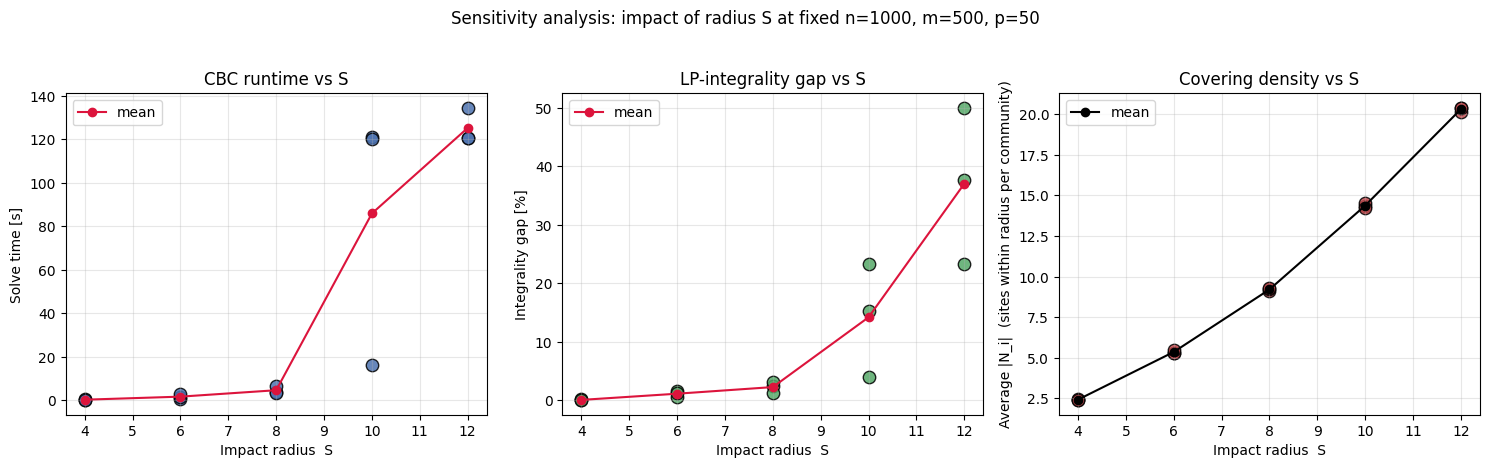

In [ ]:
sens_summary = df_sens.groupby("S").agg(
    seeds         = ("S",           "count"),
    avg_Ni        = ("avg_Ni",      "mean"),
    frac_covered  = ("frac_covered","mean"),
    avg_time_s    = ("time",        "mean"),
    avg_gap_pct   = ("gap_pct",     "mean"),
    avg_obj       = ("obj",         "mean"),
    avg_heur_gap  = ("heur_gap_pct","mean"),
).round(3)
print(sens_summary.to_string())

with open(f"{DRIVE_DIR}/sensitivity_table.tex", "w") as f:
    f.write(sens_summary.to_latex(float_format="%.3f"))

# figure: 3 panels — time vs S, integrality gap vs S, avg |N_i| vs S
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

s_vals = sorted(df_sens["S"].unique())

# Panel 1: solve time vs S
ax = axes[0]
for S in s_vals:
    sub = df_sens[df_sens["S"] == S]
    ax.scatter([S]*len(sub), sub["time"], s=80, c="#4C72B0",
               edgecolors="black", alpha=0.85)
ax.plot(s_vals, [df_sens[df_sens["S"]==S]["time"].mean() for S in s_vals],
        "o-", c="crimson", label="mean")
ax.set_xlabel("Impact radius  S")
ax.set_ylabel("Solve time [s]")
ax.set_title("CBC runtime vs S")
ax.grid(True, alpha=0.3); ax.legend()

# Panel 2: integrality gap vs S
ax = axes[1]
for S in s_vals:
    sub = df_sens[df_sens["S"] == S]
    ax.scatter([S]*len(sub), sub["gap_pct"], s=80, c="#55A868",
               edgecolors="black", alpha=0.85)
ax.plot(s_vals, [df_sens[df_sens["S"]==S]["gap_pct"].mean() for S in s_vals],
        "o-", c="crimson", label="mean")
ax.set_xlabel("Impact radius  S")
ax.set_ylabel("Integrality gap [%]")
ax.set_title("LP-integrality gap vs S")
ax.grid(True, alpha=0.3); ax.legend()

# Panel 3: covering density (avg |N_i|) vs S
ax = axes[2]
for S in s_vals:
    sub = df_sens[df_sens["S"] == S]
    ax.scatter([S]*len(sub), sub["avg_Ni"], s=80, c="#C44E52",
               edgecolors="black", alpha=0.85)
ax.plot(s_vals, [df_sens[df_sens["S"]==S]["avg_Ni"].mean() for S in s_vals],
        "o-", c="black", label="mean")
ax.set_xlabel("Impact radius  S")
ax.set_ylabel("Average |N_i|  (sites within radius per community)")
ax.set_title("Covering density vs S")
ax.grid(True, alpha=0.3); ax.legend()

plt.suptitle("Sensitivity analysis: impact of radius S at fixed n=1000, m=500, p=50", y=1.03)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/figures/fig_sensitivity_S.png", dpi=200, bbox_inches="tight")
plt.show()

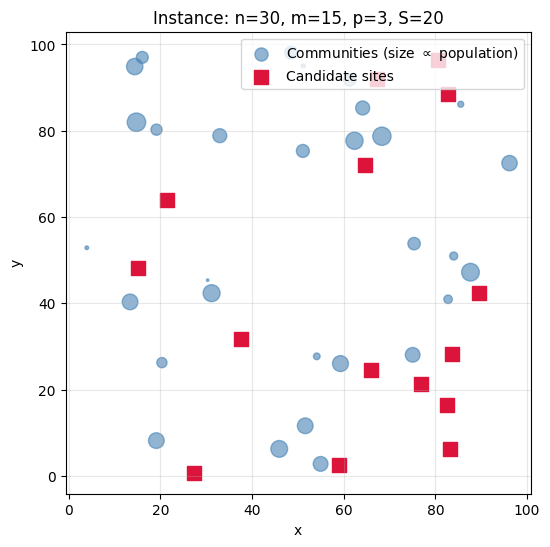

Saved fig_instance.png


In [ ]:
# Regenerate the instance used in day 1 for the example figure
inst = generate_instance(n=30, m=15, p=3, S=20, seed=1)

plt.figure(figsize=(6, 6))
plt.scatter(inst["comm_xy"][:, 0], inst["comm_xy"][:, 1],
            s=inst["a"] / 50, c="steelblue", alpha=0.6,
            label="Communities (size $\\propto$ population)")
plt.scatter(inst["site_xy"][:, 0], inst["site_xy"][:, 1],
            s=100, marker="s", c="crimson",
            label="Candidate sites")
plt.legend(loc="upper right")
plt.title(f"Instance: n={inst['n']}, m={inst['m']}, p={inst['p']}, S={inst['S']}")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(alpha=0.3)
plt.savefig(f"{DRIVE_DIR}/figures/fig_instance.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig_instance.png")

Optimum: obj=12161, open_sites=[11, 12, 13]


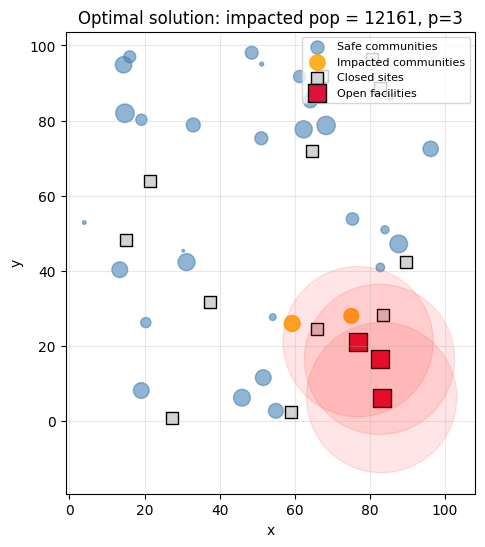

Saved fig_solution.png


In [ ]:
res = solve_milp_pulp(inst, time_limit=30, verbose=False)
open_sites = res["open_sites"]
print(f"Optimum: obj={res['obj']:.0f}, open_sites={open_sites}")

# recompute which communities are impacted by the open facilities
impacted = np.zeros(inst["n"], dtype=bool)
for i in range(inst["n"]):
    if any(j in inst["N"][i] for j in open_sites):
        impacted[i] = True

plt.figure(figsize=(6, 6))
# safe communities
plt.scatter(inst["comm_xy"][~impacted, 0], inst["comm_xy"][~impacted, 1],
            s=inst["a"][~impacted] / 50, c="steelblue", alpha=0.6,
            label="Safe communities")
# impacted communities
plt.scatter(inst["comm_xy"][impacted, 0], inst["comm_xy"][impacted, 1],
            s=inst["a"][impacted] / 50, c="orange", alpha=0.85,
            label="Impacted communities")
# closed sites
closed = [j for j in range(inst["m"]) if j not in open_sites]
plt.scatter(inst["site_xy"][closed, 0], inst["site_xy"][closed, 1],
            s=80, marker="s", c="lightgray", edgecolors="black",
            label="Closed sites")
# open facilities
plt.scatter(inst["site_xy"][open_sites, 0], inst["site_xy"][open_sites, 1],
            s=150, marker="s", c="crimson", edgecolors="black",
            label="Open facilities")
# impact circles
for j in open_sites:
    circ = plt.Circle(inst["site_xy"][j], inst["S"], color="red", alpha=0.1)
    plt.gca().add_patch(circ)

plt.legend(loc="upper right", fontsize=8)
plt.title(f"Optimal solution: impacted pop = {res['obj']:.0f}, p={inst['p']}")
plt.xlabel("x"); plt.ylabel("y")
plt.gca().set_aspect("equal")
plt.grid(alpha=0.3)
plt.savefig(f"{DRIVE_DIR}/figures/fig_solution.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig_solution.png")